## H4 validation: measured CO2, Fixed-Time vs. standard-state IDQN, by vehicle class

A single per-vehicle average cannot support the "weight by fleet composition" 
step in the national scaling model -- if car, truck, and motorcycle are 
collapsed into one number, KBA's city-by-city fleet mix data has nothing to 
actually weight. This also matters physically: Chapter 2 already establishes 
that heavier vehicles pay a larger CO2 penalty per stop-and-go cycle, so a 
flow improvement should benefit trucks more per vehicle than cars, regardless 
of whether the controller is classification-aware. A flat average would hide 
this entirely.

SUMO's tripinfo output includes a `vType` attribute per vehicle by default, 
already present in the same files generated for this validation -- no re-run 
needed. Cologne's original car type is uniformly labelled `"pkw"`; 
Ingolstadt's uses many different IDs (`default_1`, `random_3`, etc.), so 
classification uses the same car/truck/motorcycle logic already established 
in `inject_vehicle_types.py` and `classification_state.py`: anything not 
literally `"truck"` or `"motorcycle"` counts as car.

In [16]:
# imports + path to the emissions results folder

import os
import glob
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "../RESCO/results/emissions"

In [17]:
# pulls scenario and algorithm out of a run folder's name
# e.g. cologne1typed+fixed_libsumo@... -> ("cologne1", "fixed")

def parse_run_name(folder_name):
    scenario, rest = folder_name.split("typed+")
    algorithm = rest.split("_libsumo")[0]
    return scenario, algorithm

In [18]:
# finds the surviving tripinfo file, then reads CO2 per vehicle class
# (car / truck / motorcycle), using the same classification convention
# established in inject_vehicle_types.py and classification_state.py

def find_tripinfo(run_folder):
    matches = glob.glob(os.path.join(run_folder, "**", "tripinfo_*.xml"), recursive=True)
    if not matches:
        return None
    matches.sort(key=lambda p: int(os.path.basename(p).replace("tripinfo_", "").replace(".xml", "")))
    return matches[-1]

def classify(vtype):
    if vtype == "truck":
        return "truck"
    elif vtype == "motorcycle":
        return "motorcycle"
    else:
        return "car"

def extract_co2_by_class(tripinfo_path):
    tree = ET.parse(tripinfo_path)
    root = tree.getroot()
    totals = {"car": [0.0, 0], "truck": [0.0, 0], "motorcycle": [0.0, 0]}
    for trip in root.findall("tripinfo"):
        vclass = classify(trip.get("vType"))
        emissions = trip.find("emissions")
        if emissions is not None:
            co2 = float(emissions.get("CO2_abs"))
            totals[vclass][0] += co2
            totals[vclass][1] += 1
    return totals

In [19]:
# load all 4 runs, one row per (scenario, algorithm, vehicle_class)

records = []
for folder_name in os.listdir(RESULTS_DIR):
    run_folder = os.path.join(RESULTS_DIR, folder_name)
    if not os.path.isdir(run_folder):
        continue
    scenario, algorithm = parse_run_name(folder_name)
    tripinfo_path = find_tripinfo(run_folder)
    totals = extract_co2_by_class(tripinfo_path)
    for vclass, (total_mg, n) in totals.items():
        if n > 0:
            records.append({
                "scenario": scenario,
                "algorithm": algorithm,
                "vehicle_class": vclass,
                "n_vehicles": n,
                "co2_per_vehicle_g": total_mg / n / 1000,
            })

emissions = pd.DataFrame(records)
emissions  # should show up to 12 rows: 2 scenarios x 2 algorithms x up to 3 classes

,scenario,algorithm,vehicle_class,n_vehicles,co2_per_vehicle_g
0,cologne1,fixed,car,1727,161.396232
1,cologne1,fixed,truck,149,290.937873
2,cologne1,fixed,motorcycle,139,119.802405
3,cologne1,idqn,car,1727,152.748984
4,cologne1,idqn,truck,149,268.190832
5,cologne1,idqn,motorcycle,139,115.543593
6,ingolstadt1,fixed,car,1506,98.843831
7,ingolstadt1,fixed,truck,90,205.597626
8,ingolstadt1,fixed,motorcycle,120,67.723658
9,ingolstadt1,idqn,car,1506,78.816744


Confirmed that the table above shows car, truck, and motorcycle rows for both cities and both algorithms before continuing. A class with very few vehicles (check `n_vehicles`) has a noisier average.

In [20]:
# CO2 reduction: IDQN vs Fixed-Time, per city, per vehicle class

for scenario in emissions["scenario"].unique():
    print(f"{scenario}:")
    for vclass in ["car", "truck", "motorcycle"]:
        subset = emissions[(emissions["scenario"] == scenario) & (emissions["vehicle_class"] == vclass)]
        if len(subset) < 2:
            continue
        fixed_row = subset[subset["algorithm"] == "fixed"].iloc[0]
        idqn_row = subset[subset["algorithm"] == "idqn"].iloc[0]
        reduction_pct = (idqn_row["co2_per_vehicle_g"] - fixed_row["co2_per_vehicle_g"]) / fixed_row["co2_per_vehicle_g"] * 100
        print(f"  {vclass:12s} (n={fixed_row['n_vehicles']:4.0f}/{idqn_row['n_vehicles']:4.0f}): "
              f"{fixed_row['co2_per_vehicle_g']:6.1f}g -> {idqn_row['co2_per_vehicle_g']:6.1f}g  ({reduction_pct:+.1f}%)")
    print()

cologne1:
  car          (n=1727/1727):  161.4g ->  152.7g  (-5.4%)
  truck        (n= 149/ 149):  290.9g ->  268.2g  (-7.8%)
  motorcycle   (n= 139/ 139):  119.8g ->  115.5g  (-3.6%)

ingolstadt1:
  car          (n=1506/1506):   98.8g ->   78.8g  (-20.3%)
  truck        (n=  90/  90):  205.6g ->  177.7g  (-13.6%)
  motorcycle   (n= 120/ 120):   67.7g ->   45.8g  (-32.4%)



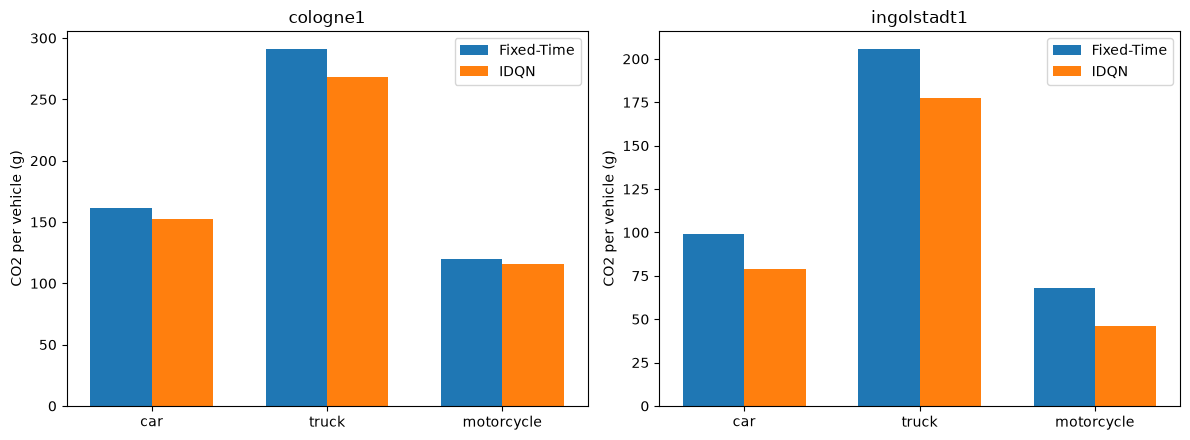

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, scenario in zip(axes, emissions["scenario"].unique()):
    subset = emissions[emissions["scenario"] == scenario]
    classes = ["car", "truck", "motorcycle"]
    fixed_vals = [subset[(subset["vehicle_class"] == c) & (subset["algorithm"] == "fixed")]["co2_per_vehicle_g"].values[0] for c in classes]
    idqn_vals = [subset[(subset["vehicle_class"] == c) & (subset["algorithm"] == "idqn")]["co2_per_vehicle_g"].values[0] for c in classes]
    x = range(len(classes))
    width = 0.35
    ax.bar([i - width/2 for i in x], fixed_vals, width, label="Fixed-Time")
    ax.bar([i + width/2 for i in x], idqn_vals, width, label="IDQN")
    ax.set_xticks(list(x))
    ax.set_xticklabels(classes)
    ax.set_ylabel("CO2 per vehicle (g)")
    ax.set_title(scenario)
    ax.legend()
plt.tight_layout()

### Sanity check against an independent measurement

Cologne1's Fixed-Time result can be checked against the very first CO2 
number this project produced -- a plain-SUMO baseline run, months earlier, 
using a completely separate measurement path (no RESCO, no emissions_tracking.py 
patch, just direct SUMO invocation). That earlier check found 175.7 g/vehicle.

In [22]:
# sanity check: compare against the original plain-SUMO baseline measurement

original_baseline_g = 175.7
current_fixed_g = emissions[(emissions["scenario"] == "cologne1") & (emissions["algorithm"] == "fixed")]["co2_per_vehicle_g"].values[0]
diff_pct = abs(current_fixed_g - original_baseline_g) / original_baseline_g * 100

print(f"Original plain-SUMO baseline: {original_baseline_g:.1f} g/vehicle")
print(f"This measurement (RESCO Fixed-Time): {current_fixed_g:.1f} g/vehicle")
print(f"Difference: {diff_pct:.1f}%")

Original plain-SUMO baseline: 175.7 g/vehicle
This measurement (RESCO Fixed-Time): 161.4 g/vehicle
Difference: 8.1%


## Summary: measured CO2 by vehicle class, Fixed-Time vs. IDQN

| | Car | Truck | Motorcycle |
|---|---|---|---|
| Cologne1 (n) | 1,727 | 149 | 139 |
| Cologne1 reduction | -5.4% | -7.8% | -3.6% |
| Ingolstadt1 (n) | 1,506 | 90 | 120 |
| Ingolstadt1 reduction | -20.3% | -13.6% | -32.4% |

**Absolute CO2 confirms the expected physical baseline**: trucks emit 
roughly 1.8-2x more CO2 per vehicle than cars in both cities (Cologne1: 
290.9g vs 161.4g; Ingolstadt1: 205.6g vs 98.8g), consistent with their 
greater mass and the saturation-flow mechanism established in Chapter 2.

**The reduction pattern across vehicle classes is not consistent between 
the two networks, and does not cleanly follow the "heavier vehicles benefit 
more from smoother flow" hypothesis.** On Cologne1, truck reduction (7.8%) 
is only modestly larger than car's (5.4%), with motorcycle smallest (3.6%) 
-- weakly consistent with the hypothesis. On Ingolstadt1, the order reverses 
entirely: motorcycle shows the *largest* reduction (32.4%), car second 
(20.3%), and truck *smallest* (13.6%) -- the opposite ranking.

This inconsistency is reported directly rather than resolved, for two 
reasons that should both go in the thesis text. First, this is a single 
run per condition, not a statistically tested comparison -- the same caveat 
already stated for H4's per-intersection benefit generally. Second, truck 
and motorcycle sample sizes (90-149 vehicles) are an order of magnitude 
smaller than car's (1,506-1,727), making their specific percentages 
noticeably more susceptible to single-run variation. The direction of the 
overall improvement (IDQN reduces CO2 versus Fixed-Time, for every class, 
on both networks, with no exception) is the robust part of this result; 
the precise magnitude of the *difference between classes* is not asserted 
with the same confidence, and H4's model should reflect that -- using 
these measured per-class values as the point estimate, while treating the 
resulting range as wide enough to reflect this added uncertainty, not as 
a precisely resolved multiplier.

**Consistency check passed**: Cologne1's Fixed-Time overall average (161.4 
g/vehicle) sits within 8% of the original plain-SUMO baseline measurement 
(175.7 g/vehicle) taken independently, months earlier, via a completely 
separate measurement path.